In [27]:
import sys
sys.path.insert(0, '..')

In [28]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [29]:
wf_wid = 512
wid = 80
oversample = 4

nwavels = 20
npoly=5

n_modes = 15
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(wf_wid, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

# extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    # exposure_from_file(ddir + 'n8jv51u6q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F187N"), crop=wid, extra_bad=np.load("bad_map.npy"), flatcorr=flatdir),
    exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid, flatcorr=flatdir),
]


223.9605 5.4
Version 4.1.1
56.8405


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


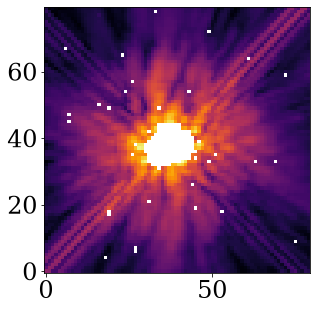

In [30]:
plt.imshow(exposures_single[0].data**0.125)

In [31]:
256-181,256-44

(75, 212)

In [32]:
exposures_single[0].hdr["TARSIAFY"]

210.276

In [33]:
# np.array([
#         256-181 - np.array(exp.hdr["TARSIAFX"],dtype=float), 
#         256-44 - np.array(exp.hdr["TARSIAFY"],dtype=float)
#     ])*0.075

In [34]:
exposures_single[0].target

'PSF-5-K0'

In [35]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(38642.3998181, dtype=float64)

In [36]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(10)+1e-3,
    "fnumber": 45.7,
    "anisotropy": 1.+1e-5,

    "outer_radius": 1.2*0.9768,
    "secondary_radius": 0.357*1.2,
    "spider_width": 0.072*1.2,
    "primary_spider": 0.0256,
    "primary_secondary": 0.330*1.2,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*6)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.05, -0.75])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44),
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        # np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075


    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.zeros(16).at[0].set(120.)#np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 3.2#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.06,-0.06])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

78.88565334649378


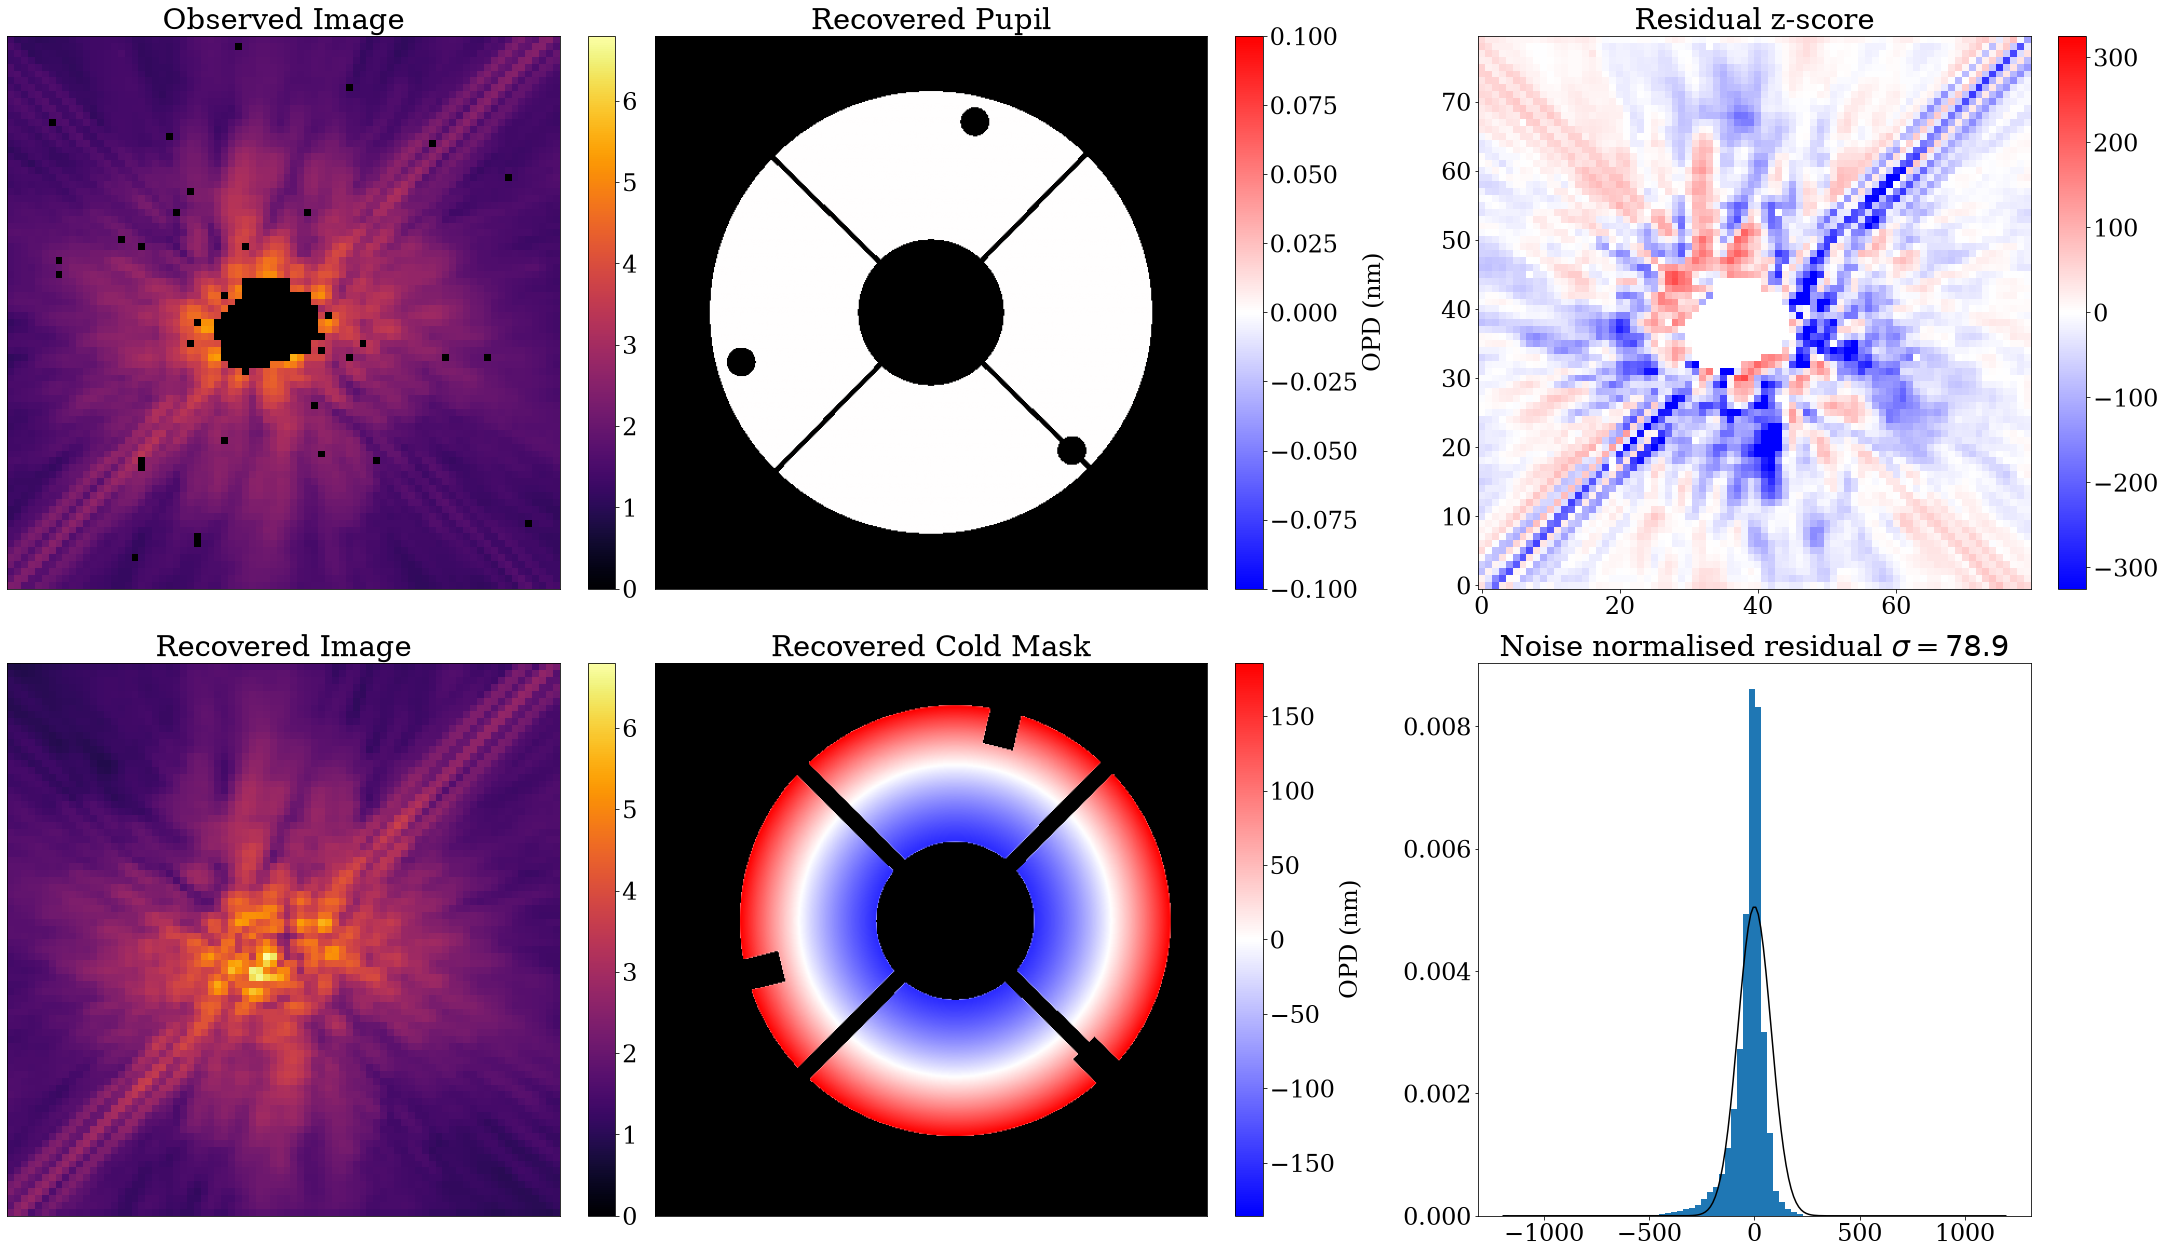

In [37]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=wf_wid)

In [38]:
# stop

In [39]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

things = {
    "primary_opd": adam(2e-1, 50),#sgd(g*2, 0),

    "spectrum": sgd(g*1, 0),
    "primary_tilt": sgd(g*1., 0),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*1., 0),

    "bias": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*1, 0),
    "cold_mask_rot": sgd(g*1., 0.),
    "primary_rot": sgd(g*3., 0),

    "primary_low": sgd(g*1, 0),

    "cold_mask_scale": sgd(g*1, 0),
    "cold_mask_shear": sgd(g*1, 0),

    "primary_shear": sgd(g*1, 0),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 0),
    "occulter_coeffs": sgd(g*1, 0),

    "secondary_radius": sgd(g*1., 0),
    "spider_width": sgd(g*1., 0),
    "primary_spider": sgd(g*1., 0),
    "primary_secondary": sgd(g*1., 0),

    "fnumber": sgd(g*1., 0),
    "anisotropy": sgd(g*1., 0),


}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*5., 15.),
    "cold_mask_tilt": sgd(g*1., 0),
    "cold_mask_opd": sgd(g*0.1, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*0.3, 70),
    "cold_mask_rot": sgd(g*0.1, 85),
    "primary_rot": sgd(g*0.1, 85),

    "primary_low": sgd(g*2., 150),

    # "cold_mask_scale": sgd(g*5, 100),
    # "cold_mask_shear": sgd(g*10, 100),

    "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 120),
    "occulter_coeffs": sgd(g*0.5, 120),

    "outer_radius": sgd(g*0.1, 120),
    "secondary_radius": sgd(g*0.1, 120),
    "spider_width": sgd(g*0.1, 120),
    "primary_spider": sgd(g*0.1, 120),
    "primary_secondary": sgd(g*0.1, 120),

    "fnumber": sgd(g*1., 200),
    "anisotropy": sgd(g*2., 200),
}

groups = list(things.keys())

In [40]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [41]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 500,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/500 [00:00<?, ?it/s]

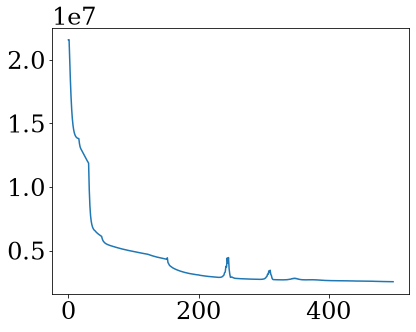

In [42]:
plt.plot(losses[:])

19
28.452776822812368


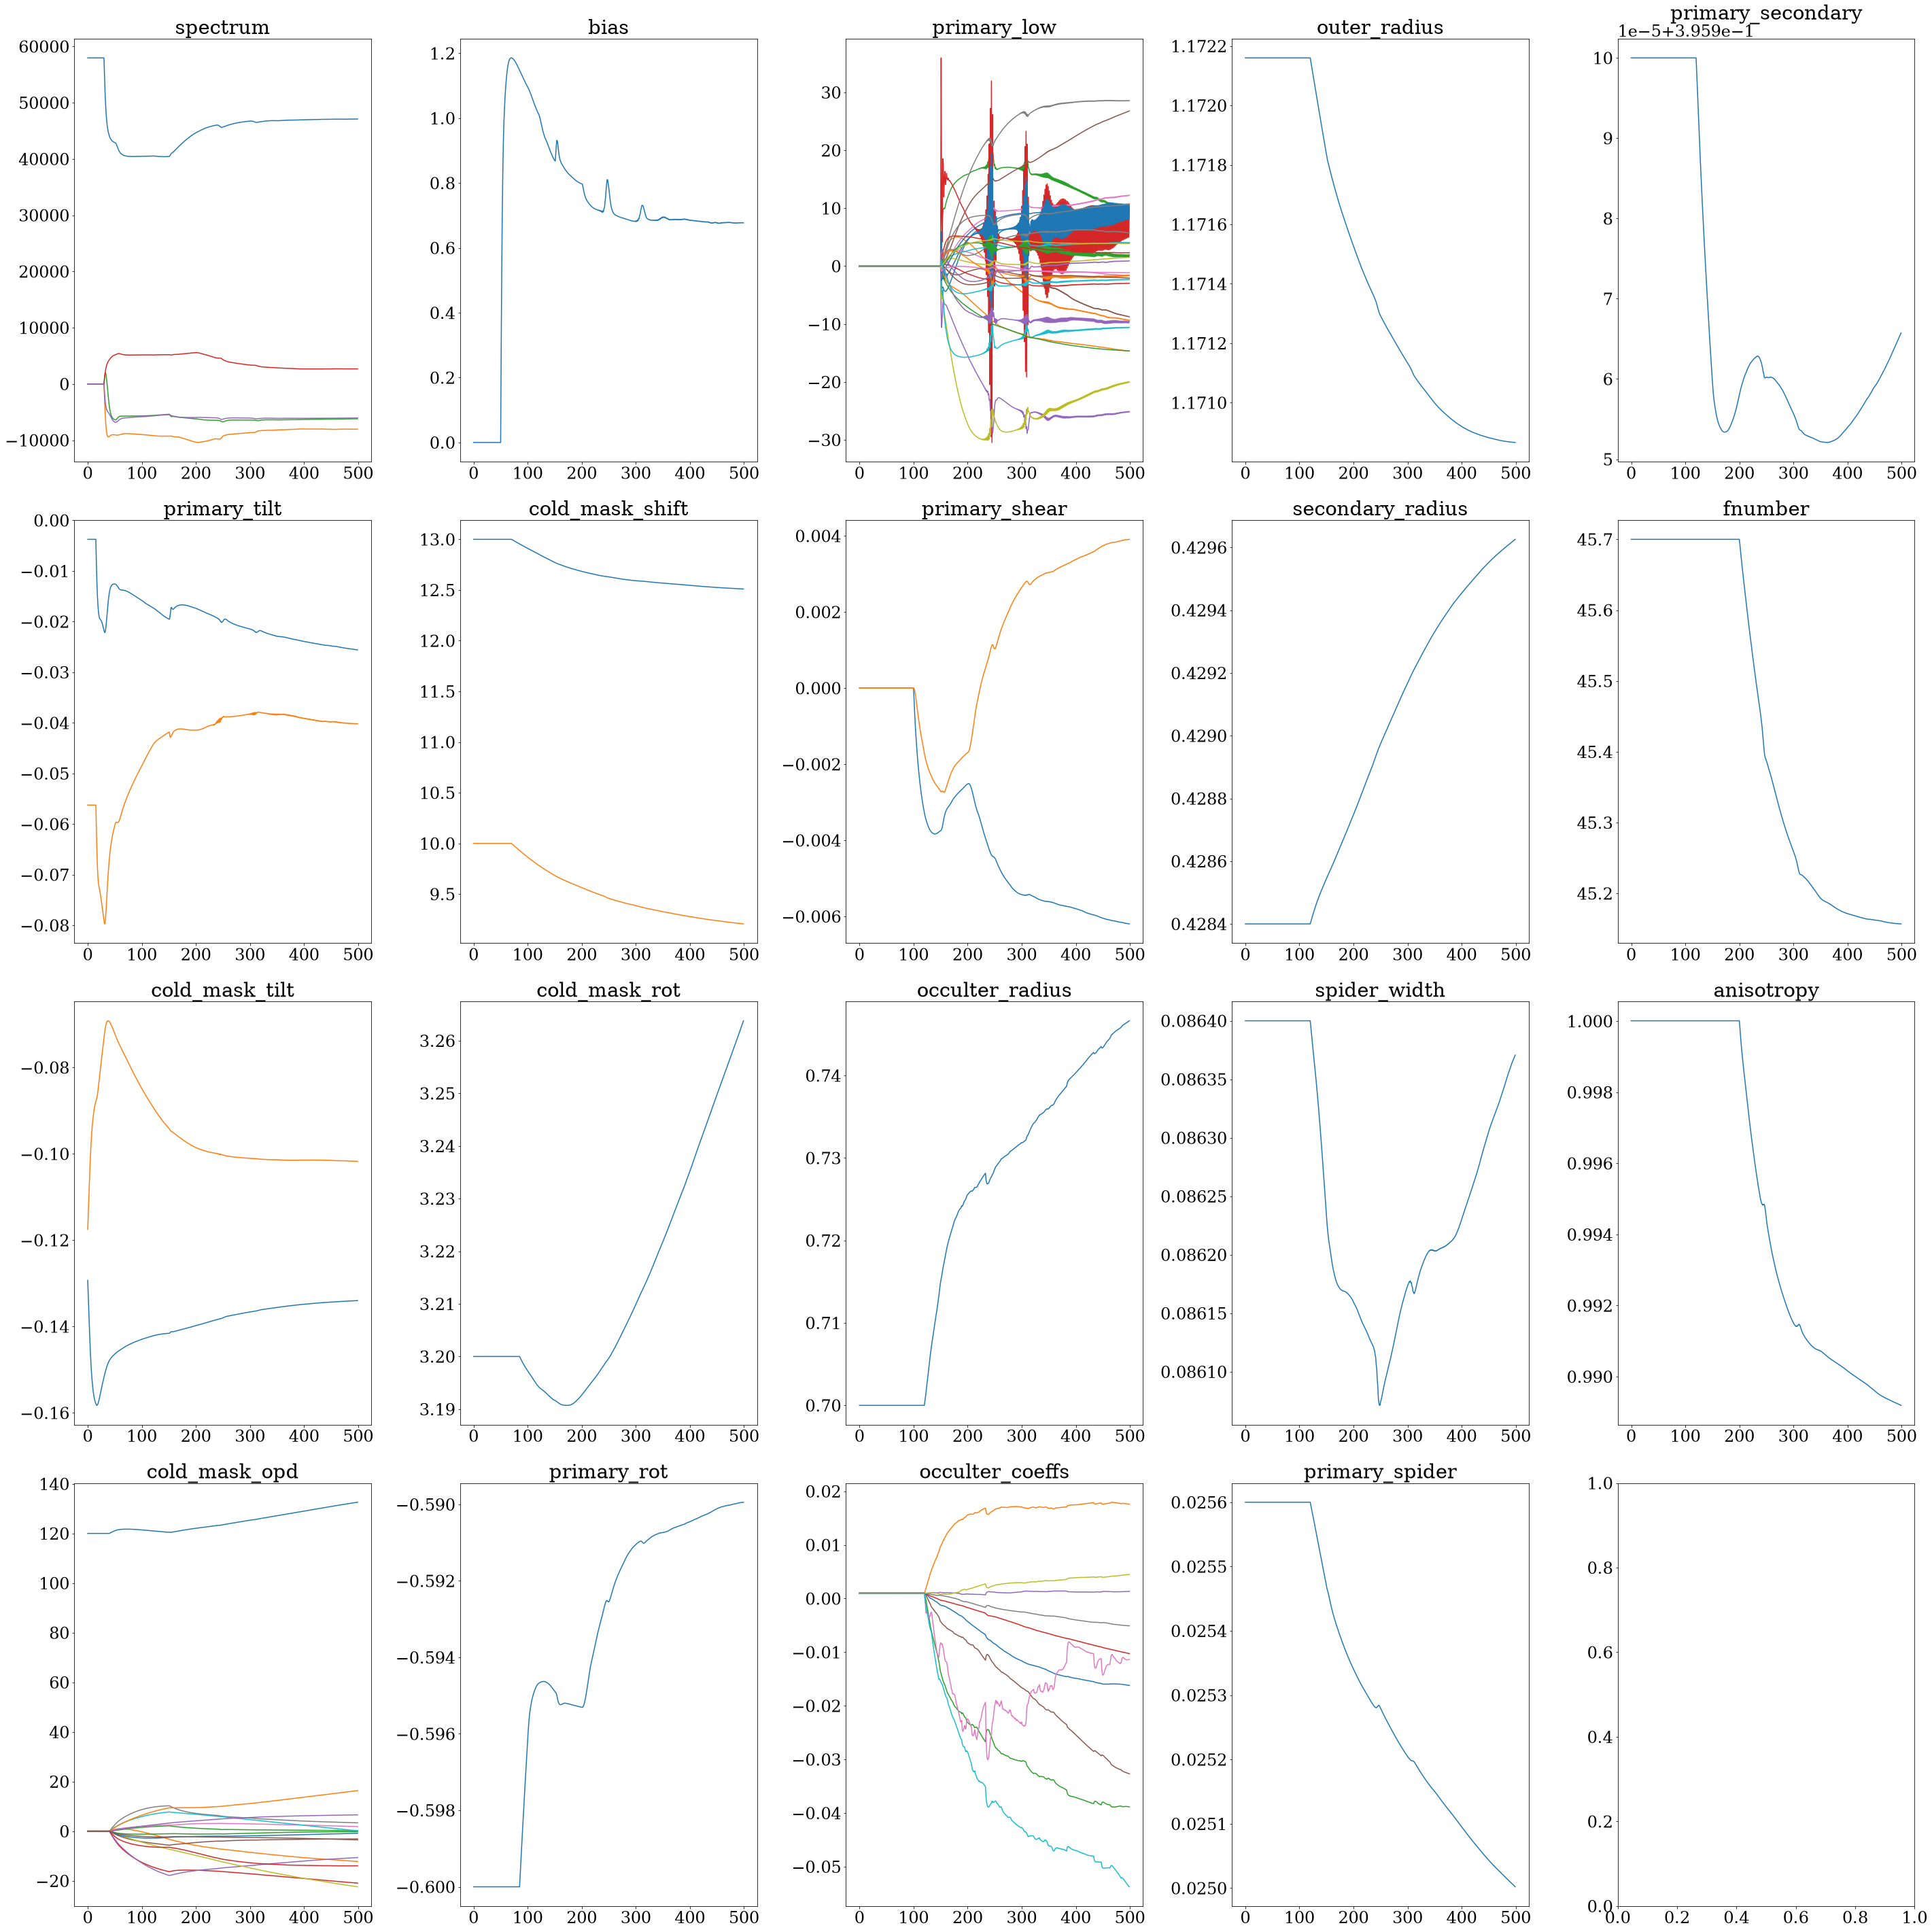

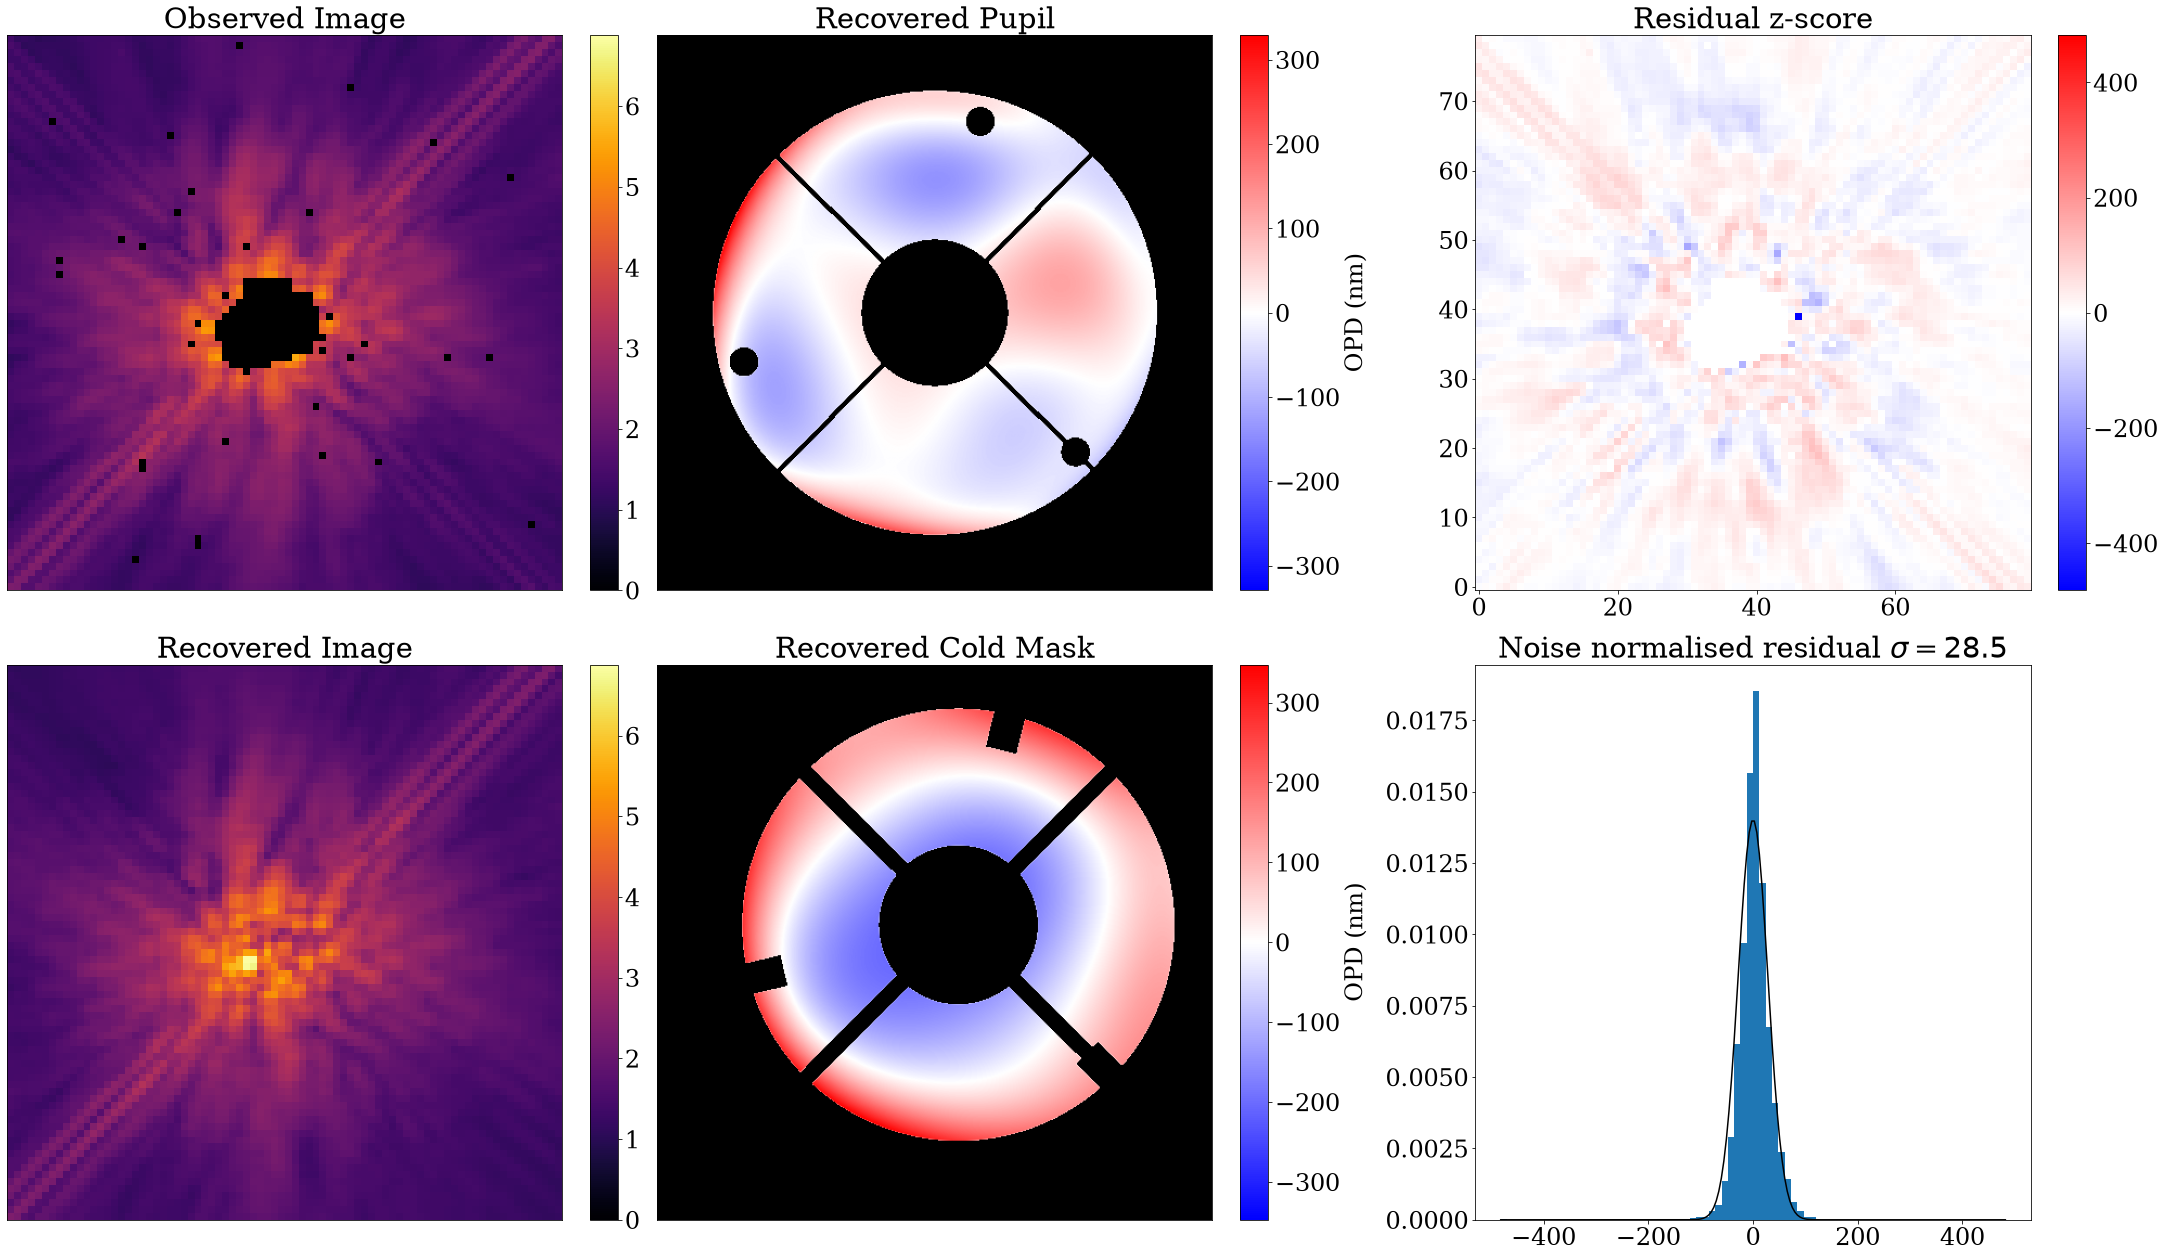

In [43]:
plot_params(params_history, list(things_start.keys()), xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=wf_wid)

In [44]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [45]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [46]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [47]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [48]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[5], ss=f64[5], normalise=False)

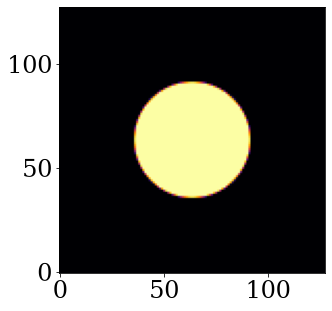

In [49]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

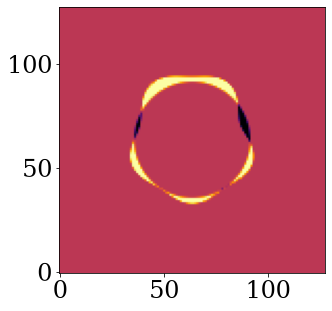

In [50]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

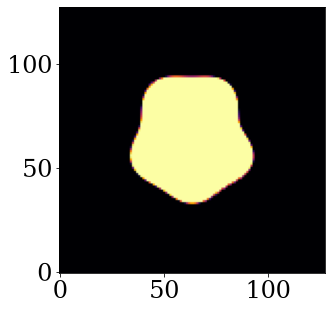

In [51]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [52]:
stop

NameError: name 'stop' is not defined

In [ ]:
params_history[-1]

{'anisotropy': Array(0.98911468, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.09830256, dtype=float64)},
 'cold_mask_opd': {'global': Array([117.18373678,   1.11957031, -19.63748532, -14.81888831,
         -33.12162896,  -4.19344118, -11.84456962,  -0.41045701,
         -18.46520131,   1.0226153 ,   0.98684144,  13.05583122,
           4.35093866, -24.5803612 ,   0.23998857,  -5.62058169],      dtype=float64)},
 'cold_mask_rot': {'global': Array(3.292926, dtype=float64)},
 'cold_mask_shift': {'global': Array([11.04240626,  7.76493284], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.02411915, -0.07111882], dtype=float64)},
 'fnumber': Array(45.14963242, dtype=float64),
 'occulter_coeffs': Array([-0.02845603,  0.0598459 , -0.05032782, -0.00237417,  0.00594103,
        -0.01636132, -0.00695577, -0.00115601,  0.01579003, -0.01564543],      dtype=float64),
 'occulter_radius': Array(0.76546535, dtype=float64),
 'primary_low': {'n8jv51u6q': Array([ -9.41828465,  18.73126824,  -4.5

In [ ]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [ ]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 3000,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

  0%|          | 0/3000 [00:00<?, ?it/s]

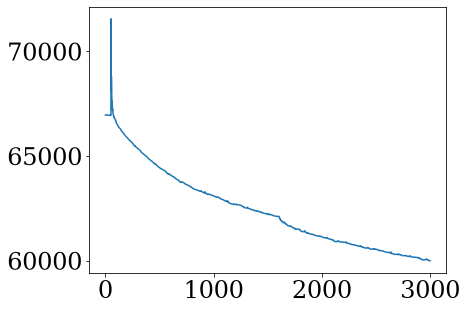

In [ ]:
plt.plot(losses[:])

In [ ]:
losses[-1]

Array(59999.84286838, dtype=float64)

21
4.792139800249841


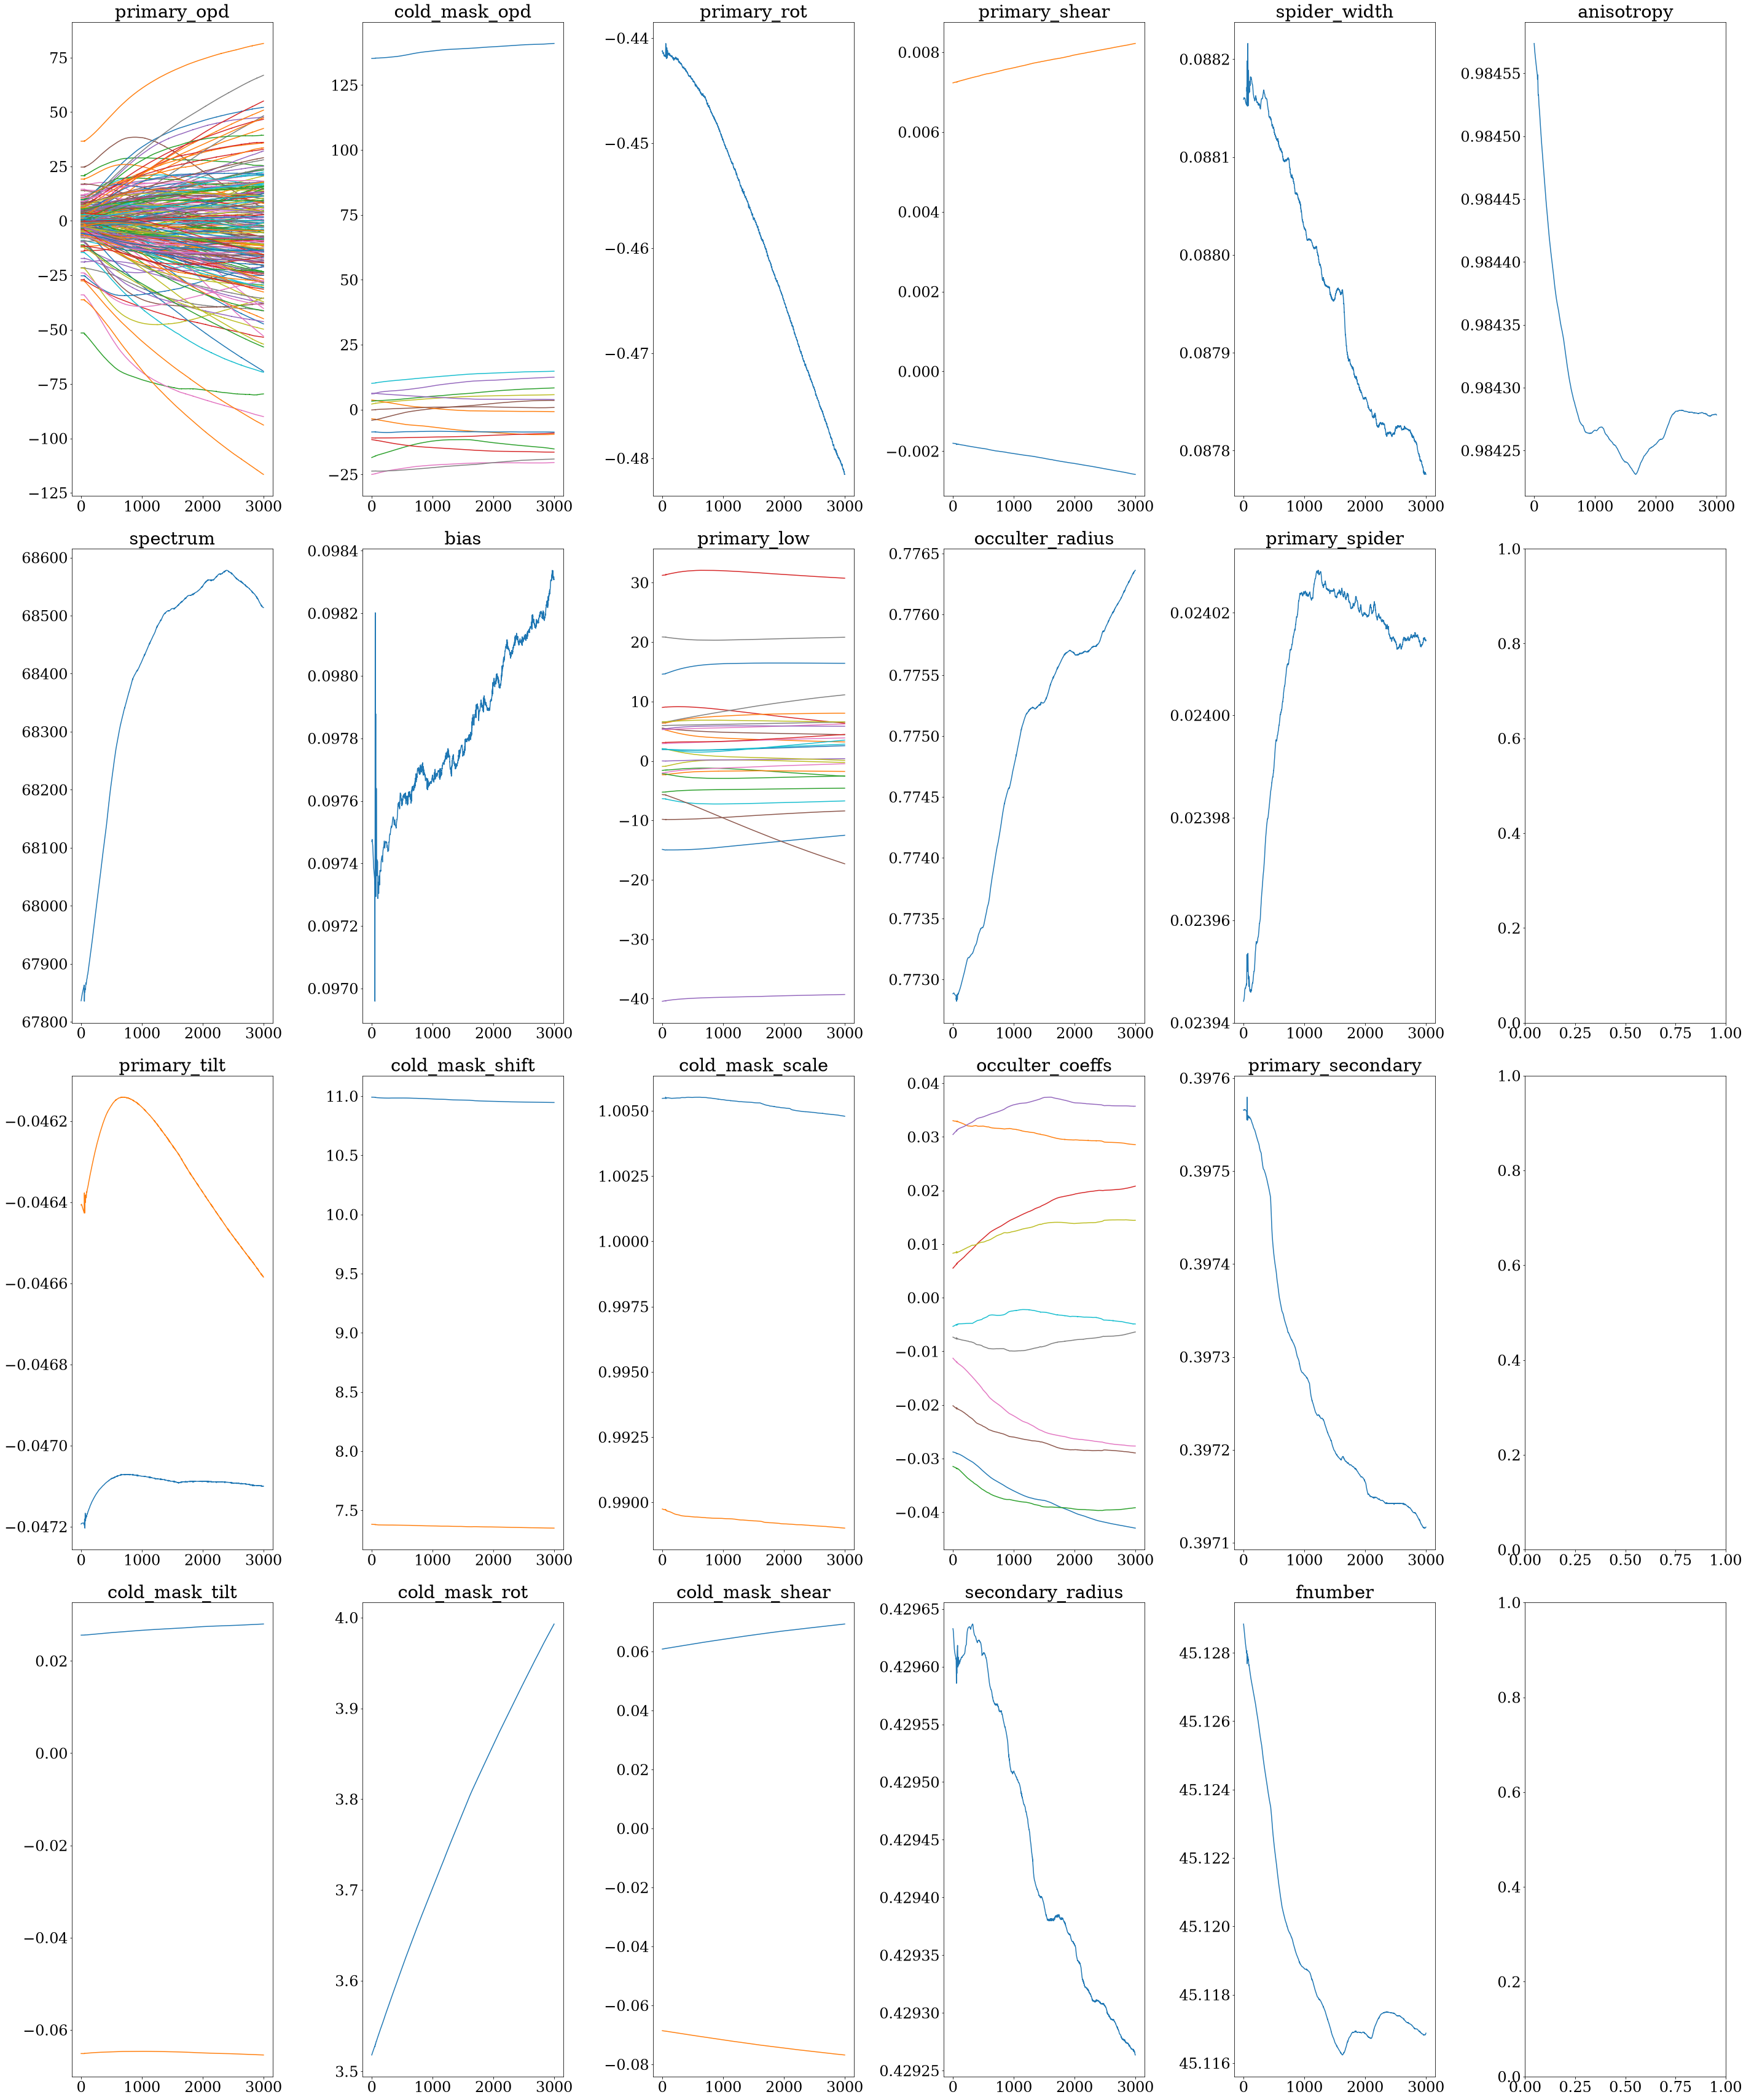

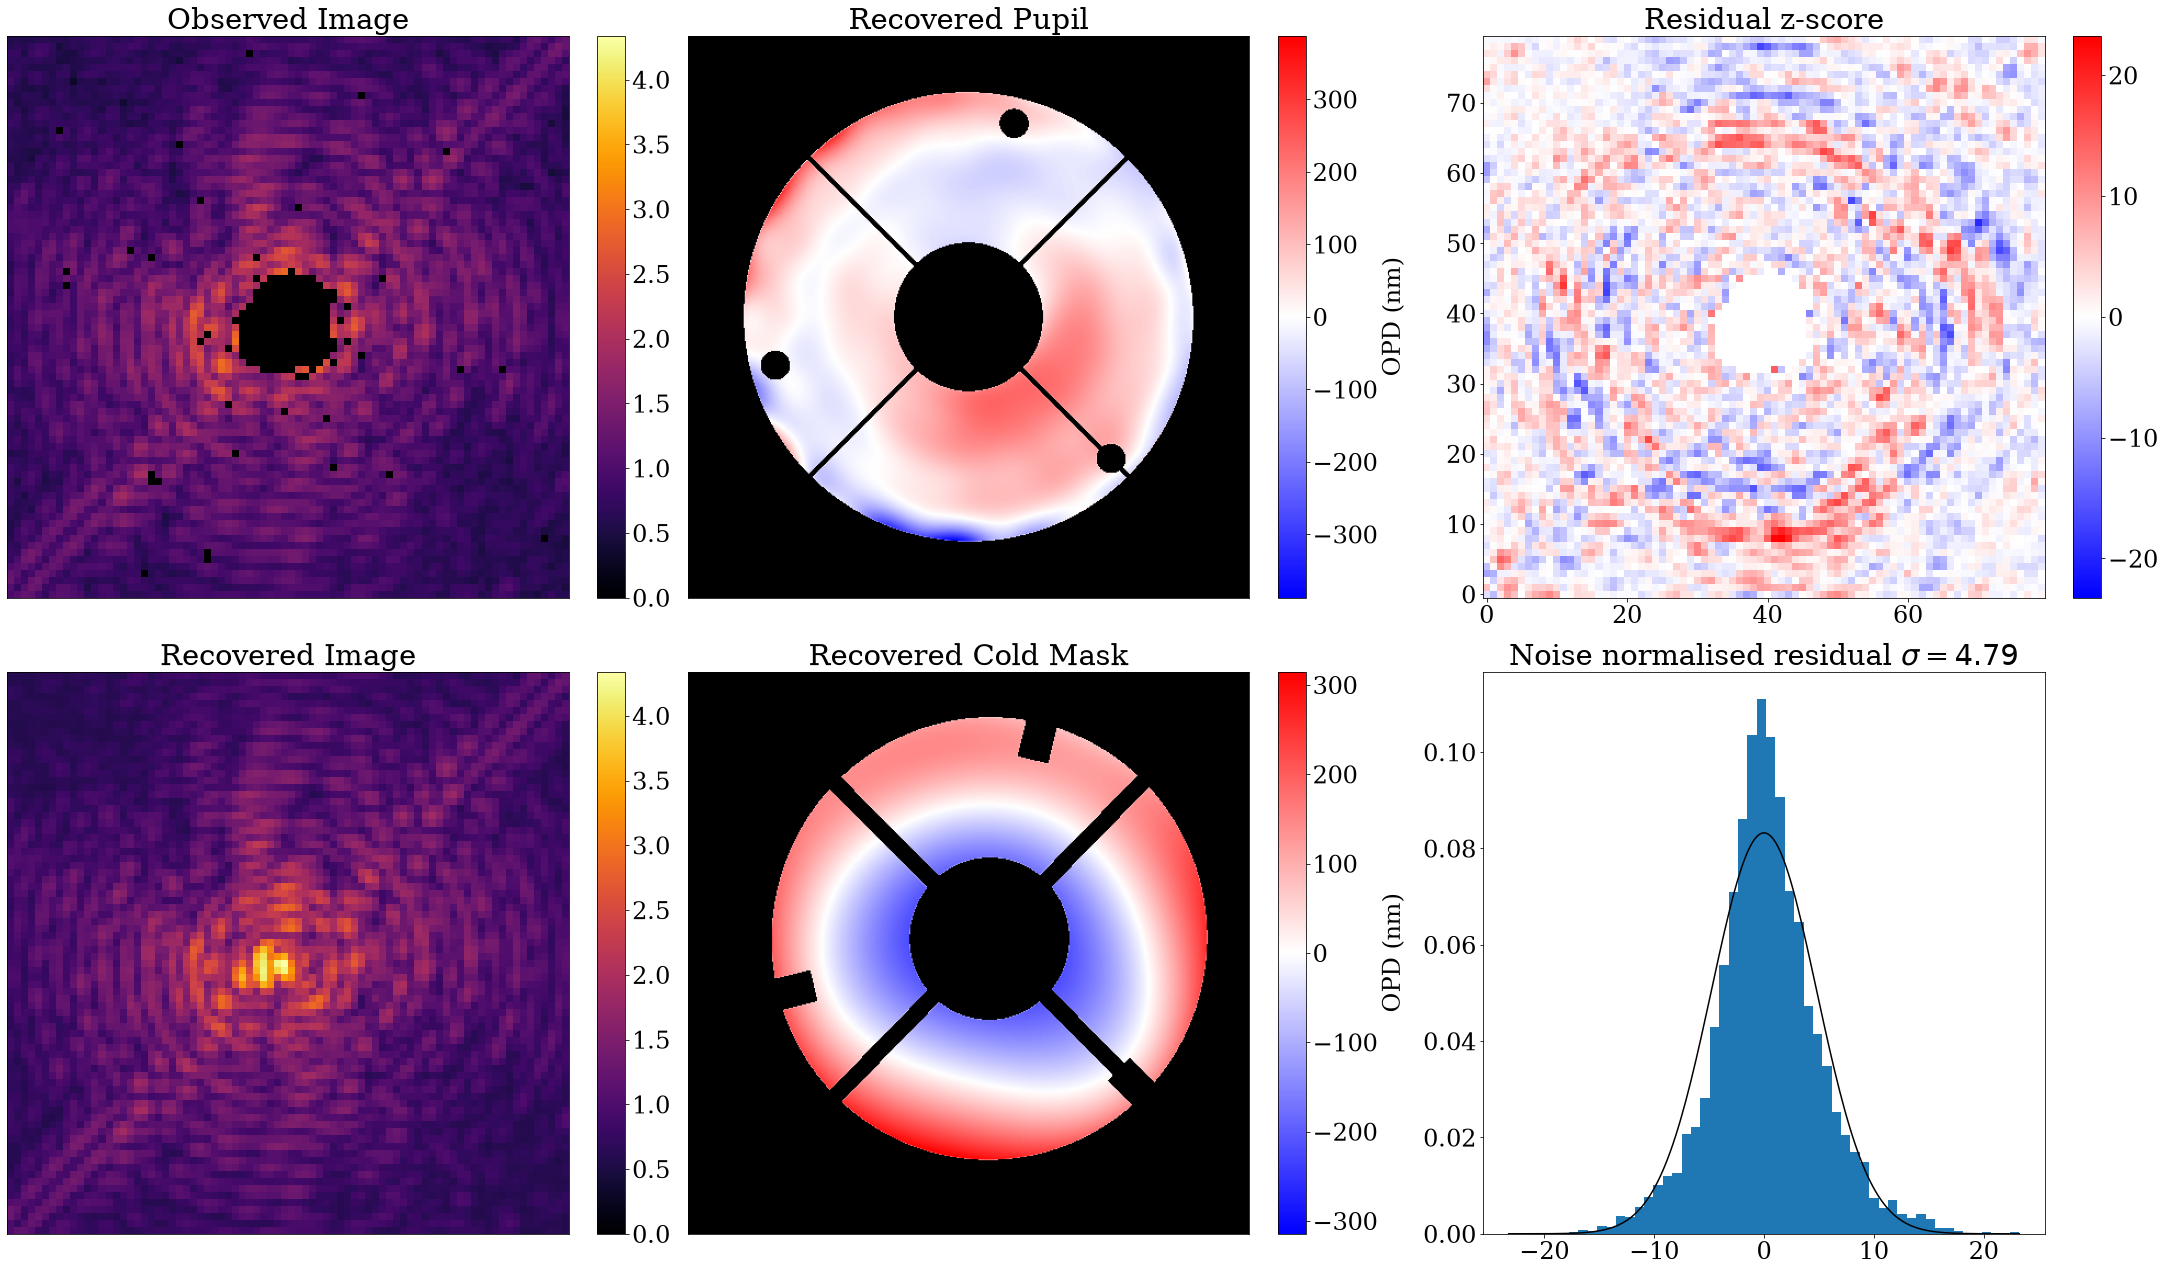

In [ ]:
plot_params(params_history, groups, xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, wf_size=wf_wid, percentile=100)

([], [])

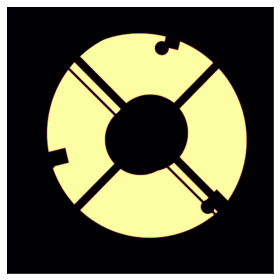

In [ ]:
model = ModelParams(params_history[-1]).inject(model_single)
optics = exposures_single[0].fit.update_optics(model, exposures_single[0])
coords = dlu.pixel_coords(512, model.optics.diameter)
support = optics.primary.transmission(coords,2.4/512) * optics.cold_mask.transmission(coords,2.4/512)
plt.imshow(support)
plt.xticks([])
plt.yticks([])

([], [])

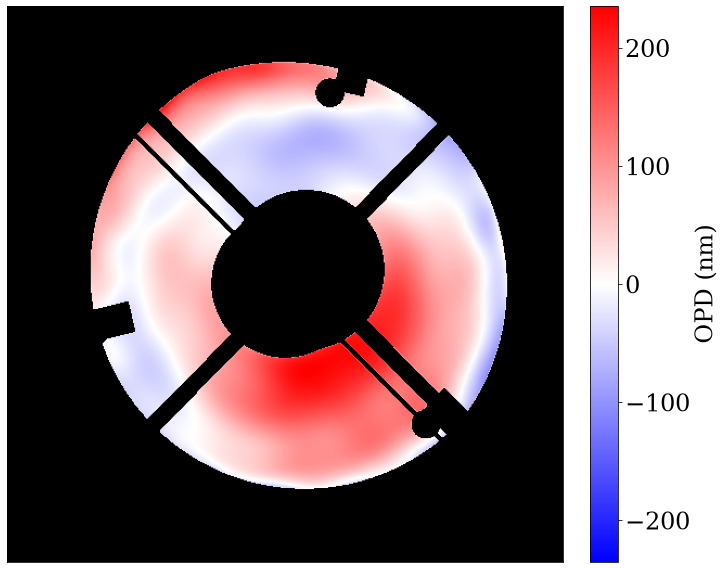

In [ ]:
plt.figure(figsize=(10,10), layout="compressed")
opd = (optics.primary_opd.eval_basis() + optics.primary_low.eval_basis(coords))*1e9
support_mask = support.at[support < .5].set(np.nan)

cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)
olim = np.nanmax(np.abs(opd*support_mask))
plt.imshow(support_mask*opd,cmap=cmap,vmin=-olim, vmax=olim)
plt.colorbar().set_label("OPD (nm)")
plt.xticks([])
plt.yticks([])

In [ ]:
np.sqrt(3**2 * 100)

Array(30., dtype=float64, weak_type=True)

In [ ]:
params_history[-1]

{'anisotropy': Array(0.98427834, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.09830764, dtype=float64)},
 'cold_mask_opd': {'global': Array([141.03623805,  -9.49996436, -15.14550598, -16.38727917,
          12.47719501,   3.53113547, -20.38535671, -19.03841748,
           5.74764602,  14.78550917,  -8.67265142,  -0.77349227,
           8.35202427,  -9.05219606,   3.86465147,   0.81954895],      dtype=float64)},
 'cold_mask_rot': {'global': Array(3.99293013, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.00479045, 0.98901366], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.06934637, -0.07682512], dtype=float64)},
 'cold_mask_shift': {'global': Array([10.94581788,  7.34962957], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.02799741, -0.06544299], dtype=float64)},
 'fnumber': Array(45.1168743, dtype=float64),
 'occulter_coeffs': Array([-0.04298179,  0.02855312, -0.03916995,  0.0208086 ,  0.0357182 ,
        -0.02895576, -0.02766793, -0.00639146,  0.014431

In [ ]:
np.save("params.npy", params_history[-1])

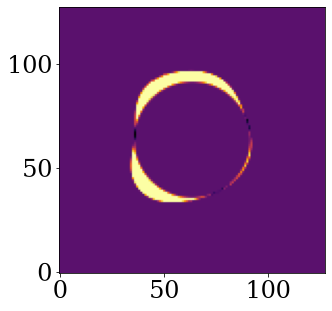

In [ ]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [ ]:
jsp.stats.norm.logpdf(200, 1, 1)

Array(-19801.41893853, dtype=float64, weak_type=True)

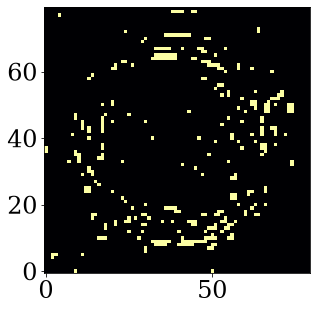

In [ ]:
final_model = ModelParams(params_history[-1]).inject(model_single)


for exp in exposures_single:
    fit = exp.fit(model, exp)
    resid = np.nan_to_num((exp.data - fit)/exp.err)
    bad_map = np.abs(resid)>10
    plt.imshow(bad_map)

In [ ]:
# np.save("bad_map.npy", bad_map)